# Promotions Analysis

This notebook analyzes the cleaned promotions dataset for the Italian Restaurant Analytics project.

The objective is to evaluate promotion usage, promotional value, monthly trends, and the relative impact of different promotions on overall promotional activity.

## Analysis Scope

- Promotion usage analysis
- Promotional value analysis
- Top-performing promotions
- Monthly promotional trends
- Promotion concentration
- Key business insights

In [20]:
# Import the libraries required for data analysis and visualization

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [21]:
# Load the cleaned promotions dataset and display the first five rows

df = pd.read_excel("../data/cleaned/promotions_cleaned.xlsx")
df.head()

,Date,Promotion,Uses,Discount Amount
0,2025-03-01,15% DESC. EMPLEADOS,23,67.92
1,2025-03-01,15% DESC. BOCATTO,4,52.28
2,2025-03-01,25% WISHKYS PREMIUM,4,59.71
3,2025-03-01,3x2 OUT 4-7PM,1,9.90
4,2025-03-01,10% GRANDE TABLE,185,1857.05


In [22]:
# Inspect the promotions dataset structure, size, and data types

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (147, 4)

Column names:
['Date', 'Promotion', 'Uses', 'Discount Amount']

Data types:
Date               datetime64[ns]
Promotion                  object
Uses                        int64
Discount Amount           float64
dtype: object


## Promotion Summary

This section provides a general overview of promotional activity, including total promotion uses, total discount amount, average discount amount, and the number of unique promotions.

In [23]:
# Calculate key summary metrics for promotional activity

total_uses = df["Uses"].sum()
total_discount = df["Discount Amount"].sum()
average_discount_per_use = total_discount / total_uses
unique_promotions = df["Promotion"].nunique()

print(f"Total promotion uses: {total_uses:,}")
print(f"Total discount amount: ${total_discount:,.2f}")
print(f"Average discount per use: ${average_discount_per_use:,.2f}")
print(f"Unique promotions: {unique_promotions}")

Total promotion uses: 8,295
Total discount amount: $90,189.53
Average discount per use: $10.87
Unique promotions: 21


## Top Promotions by Uses

This section identifies the most frequently used promotions during the analyzed period, helping determine which promotional offers generated the highest customer participation.

In [24]:
# Aggregate promotion uses and rank promotions from highest to lowest usage

promotion_usage = (
    df.groupby("Promotion")["Uses"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

promotion_usage.head(10)

,Promotion,Uses
0,3x2 SIEMPRE,3823
1,10% GRANDE TABLE,2438
2,100% PROPIETARIOS,541
3,CORTESIA AL PRODUCTO,351
4,15% DESC. EMPLEADOS,218
5,V&E&L FEBRERO 2026,159
6,50% MODO TASTY,141
7,15 % DESC. WHISKYS,138
8,10% DESCUENTO BARRA,121
9,DESC MODO TASTY 50%,88


### Top Promotions by Uses Visualization

The following horizontal bar chart displays the seven most frequently used promotions, highlighting the promotional offers with the highest level of customer participation.

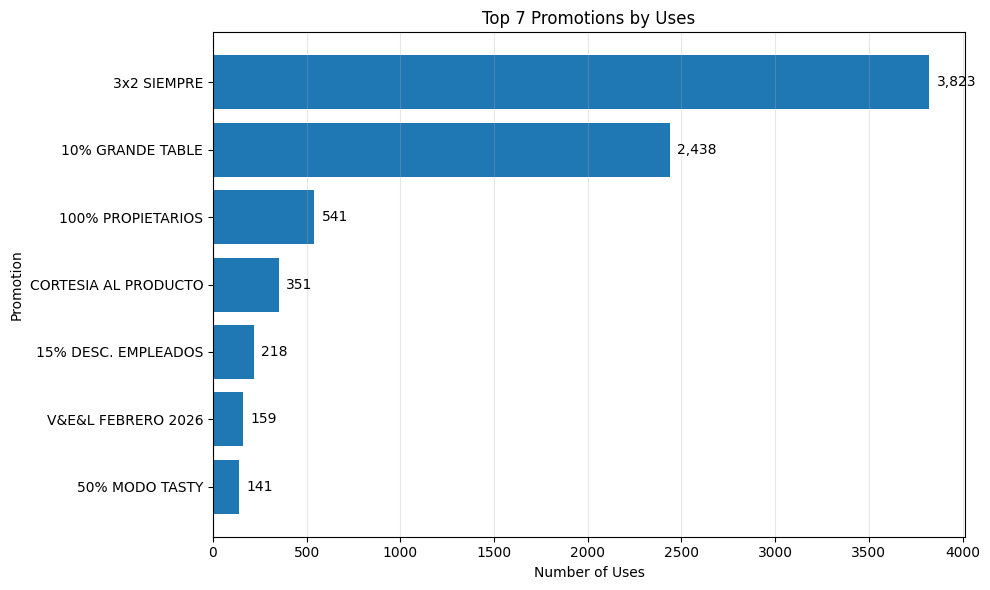

In [25]:
# Create a horizontal bar chart for the seven most frequently used promotions

top_promotions_usage = promotion_usage.head(7)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_promotions_usage["Promotion"],
    top_promotions_usage["Uses"]
)

plt.title("Top 7 Promotions by Uses")
plt.xlabel("Number of Uses")
plt.ylabel("Promotion")

# Display the most-used promotion at the top
plt.gca().invert_yaxis()

# Add usage labels at the end of each bar
for bar, value in zip(bars, top_promotions_usage["Uses"]):
    plt.text(
        value + 40,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The promotion usage analysis shows a strong concentration in two offers. `3x2 SIEMPRE` was the most frequently used promotion with 3,823 uses, followed by `10% GRANDE TABLE` with 2,438 uses.

Together, these two promotions account for the majority of promotional activity, while the remaining offers show substantially lower usage levels. This suggests that customer participation is highly concentrated in a small number of promotions.

## Top Promotions by Discount Amount

This section identifies the promotions associated with the highest total discount amounts, helping evaluate which promotional offers represented the greatest monetary impact during the analyzed period.

In [26]:
# Aggregate total discount amount by promotion and rank from highest to lowest

promotion_discount = (
    df.groupby("Promotion")["Discount Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

promotion_discount.head(10).style.format({
    "Discount Amount": "${:,.2f}"
})

,Promotion,Discount Amount
0,3x2 SIEMPRE,"$45,045.70"
1,10% GRANDE TABLE,"$21,141.53"
2,100% PROPIETARIOS,"$10,052.87"
3,50% MODO TASTY,"$4,945.45"
4,CORTESIA AL PRODUCTO,"$2,072.96"
5,15 % DESC. WHISKYS,"$1,402.61"
6,V&E&L FEBRERO 2026,"$1,171.92"
7,DESC MODO TASTY 50%,$974.02
8,30% PROPIETARIOS,$766.34
9,15% DESC. BOCATTO,$619.61


### Top Promotions by Discount Amount Visualization

The following horizontal bar chart shows the seven promotions associated with the highest total discount amounts, highlighting the offers with the greatest monetary impact.

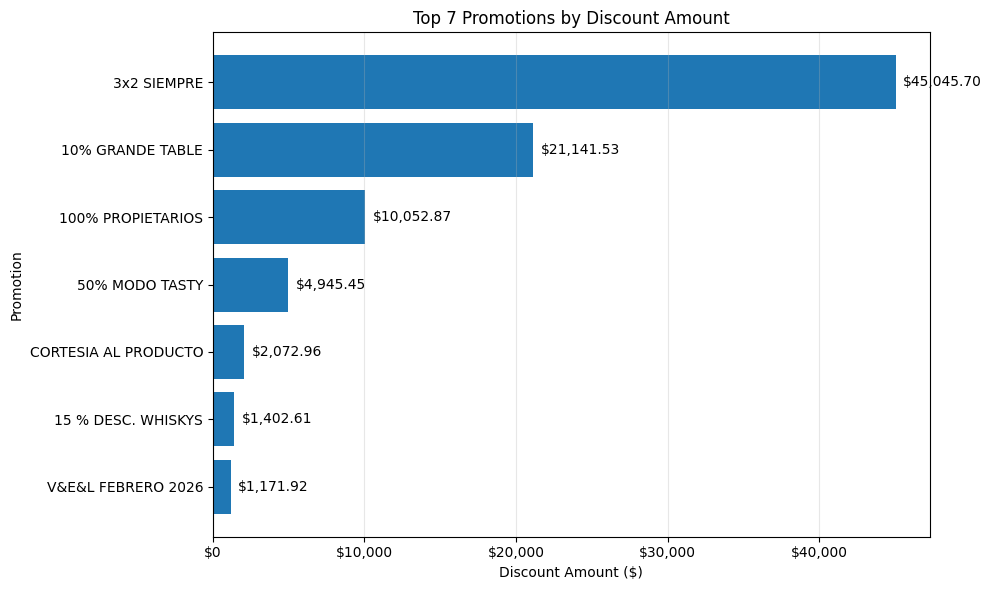

In [27]:
# Create a horizontal bar chart for the seven promotions with the highest discount amounts

top_promotions_discount = promotion_discount.head(7)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_promotions_discount["Promotion"],
    top_promotions_discount["Discount Amount"]
)

plt.title("Top 7 Promotions by Discount Amount")
plt.xlabel("Discount Amount ($)")
plt.ylabel("Promotion")

# Display the highest discount amount at the top
plt.gca().invert_yaxis()

# Format the horizontal axis as currency
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Add discount amount labels at the end of each bar
for bar, value in zip(bars, top_promotions_discount["Discount Amount"]):
    plt.text(
        value + 500,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

`3x2 SIEMPRE` generated the highest total discount amount at $45,045.70, followed by `10% GRANDE TABLE` at $21,141.53 and `100% PROPIETARIOS` at $10,052.87.

The monetary impact of promotions is highly concentrated in a small number of offers. The three leading promotions account for most of the total discount amount, indicating that promotional cost is driven primarily by a limited set of campaigns rather than being evenly distributed across all promotions.

## Average Discount per Use

This section evaluates the average monetary discount associated with each use of a promotion, helping identify offers that generate a relatively high or low discount cost per redemption.

In [28]:
# Calculate the average discount amount per use for each promotion

promotion_efficiency = (
    df.groupby("Promotion")
    .agg({
        "Uses": "sum",
        "Discount Amount": "sum"
    })
    .reset_index()
)

promotion_efficiency["Average Discount per Use"] = (
    promotion_efficiency["Discount Amount"] / promotion_efficiency["Uses"]
)

promotion_efficiency = promotion_efficiency.sort_values(
    "Average Discount per Use",
    ascending=False
)

promotion_efficiency.head(10).style.format({
    "Discount Amount": "${:,.2f}",
    "Average Discount per Use": "${:,.2f}"
})

,Promotion,Uses,Discount Amount,Average Discount per Use
3,10% DESCUENTO VIVE MAS,1,$53.96,$53.96
15,50% MODO TASTY,141,"$4,945.45",$35.07
18,DESCUENTO CERTIFICADO DE CONSUMO,2,$64.00,$32.00
10,30 % DESC. B.I.,8,$229.92,$28.74
5,100% PROPIETARIOS,541,"$10,052.87",$18.58
9,25% WISHKYS PREMIUM,7,$128.74,$18.39
11,30% PROPIETARIOS,46,$766.34,$16.66
13,3x2 SIEMPRE,3823,"$45,045.70",$11.78
17,DESC MODO TASTY 50%,88,$974.02,$11.07
6,15 % DESC. WHISKYS,138,"$1,402.61",$10.16


### Average Discount per Use Visualization

The following horizontal bar chart shows the seven promotions with the highest average discount amount per use, helping identify offers with greater monetary impact per redemption.

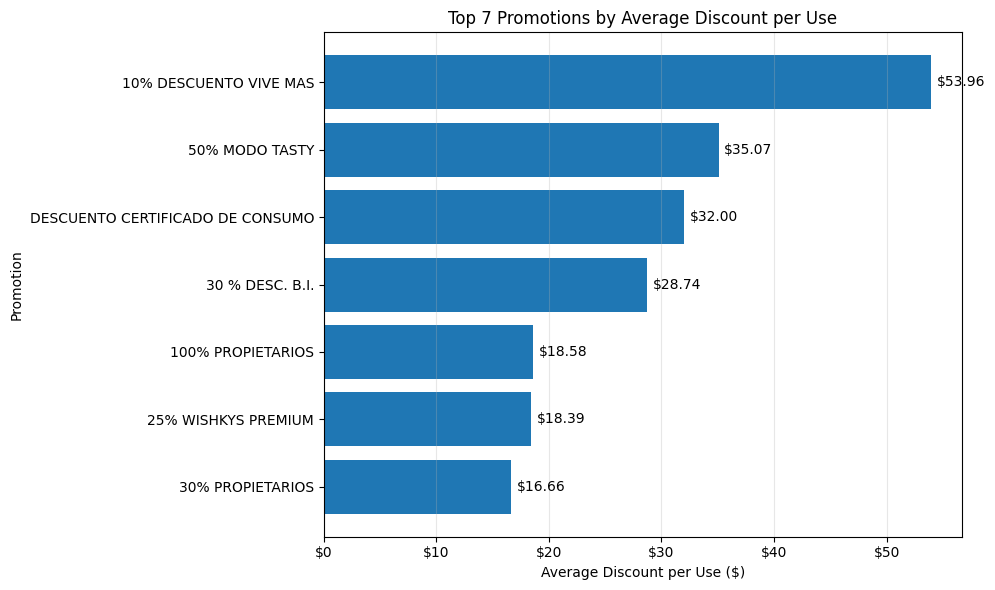

In [29]:
# Create a horizontal bar chart for promotions with the highest average discount per use

top_average_discount = promotion_efficiency.head(7)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_average_discount["Promotion"],
    top_average_discount["Average Discount per Use"]
)

plt.title("Top 7 Promotions by Average Discount per Use")
plt.xlabel("Average Discount per Use ($)")
plt.ylabel("Promotion")

# Display the highest average discount at the top
plt.gca().invert_yaxis()

# Format the horizontal axis as currency
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Add value labels at the end of each bar
for bar, value in zip(
    bars,
    top_average_discount["Average Discount per Use"]
):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The highest average discount per use was recorded by `10% DESCUENTO VIVE MAS` at $53.96 per redemption, followed by `50% MODO TASTY` at $35.07 and `DESCUENTO CERTIFICADO DE CONSUMO` at $32.00.

However, some of the highest averages are based on very few uses, which means they should be interpreted with caution. For example, `10% DESCUENTO VIVE MAS` had only one recorded use, while `DESCUENTO CERTIFICADO DE CONSUMO` had two.

Among promotions with more substantial usage, `50% MODO TASTY` stands out with 141 uses and an average discount of $35.07 per use, indicating a relatively high discount intensity compared with other frequently used promotions.

## Monthly Promotion Activity

This section analyzes monthly promotional activity by comparing the total number of promotion uses with the total discount amount generated each month.

In [30]:
 # Aggregate monthly promotion uses and total discount amount

monthly_promotions = (
    df.groupby("Date")
    .agg({
        "Uses": "sum",
        "Discount Amount": "sum"
    })
    .reset_index()
)

monthly_promotions.style.format({
    "Uses": "{:,.0f}",
    "Discount Amount": "${:,.2f}"
})   

,Date,Uses,Discount Amount
0,2025-03-01 00:00:00,650,"$6,471.27"
1,2025-04-01 00:00:00,514,"$5,596.78"
2,2025-05-01 00:00:00,597,"$6,346.34"
3,2025-06-01 00:00:00,716,"$7,404.55"
4,2025-07-01 00:00:00,594,"$6,924.22"
5,2025-08-01 00:00:00,608,"$6,499.91"
6,2025-09-01 00:00:00,615,"$6,494.46"
7,2025-10-01 00:00:00,677,"$7,237.65"
8,2025-11-01 00:00:00,639,"$6,214.21"
9,2025-12-01 00:00:00,735,"$7,205.55"


### Monthly Promotion Activity Visualization

The following combined chart compares monthly promotion uses with the total discount amount, allowing both customer participation and promotional monetary impact to be evaluated over time.

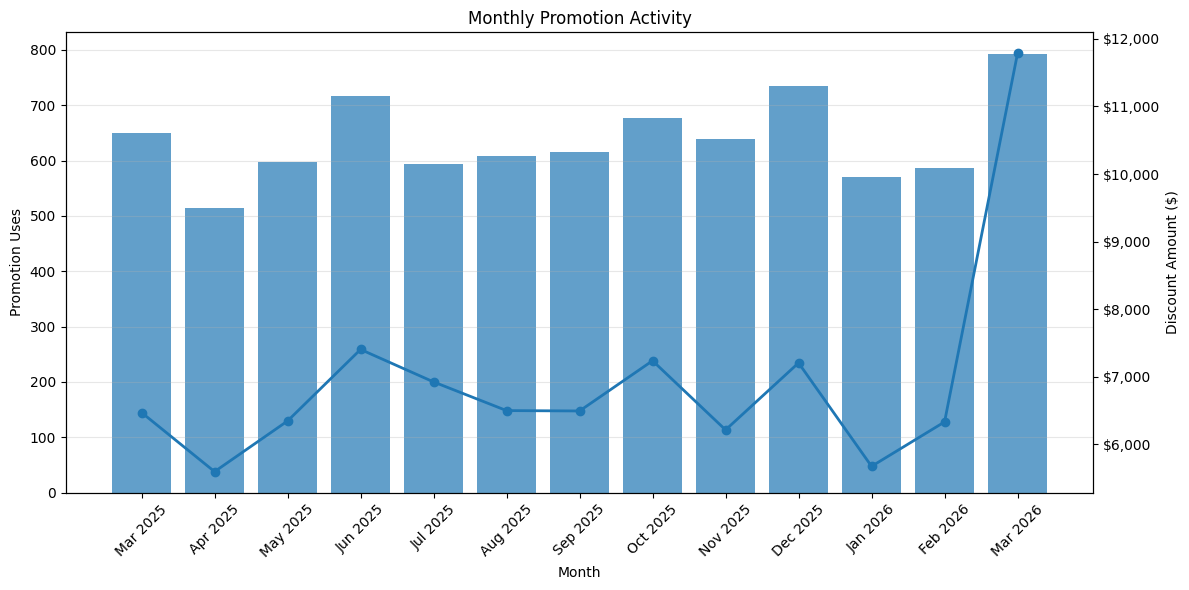

In [31]:
# Create a combined chart to compare monthly promotion uses and discount amounts

monthly_promotions["Month"] = monthly_promotions["Date"].dt.strftime("%b %Y")

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot promotion uses as bars on the primary axis
bars = ax1.bar(
    monthly_promotions["Month"],
    monthly_promotions["Uses"],
    alpha=0.7,
    label="Promotion Uses"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Promotion Uses")
ax1.tick_params(axis="x", rotation=45)

# Create a secondary axis for discount amount
ax2 = ax1.twinx()

ax2.plot(
    monthly_promotions["Month"],
    monthly_promotions["Discount Amount"],
    marker="o",
    linewidth=2,
    label="Discount Amount"
)

ax2.set_ylabel("Discount Amount ($)")

ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.title("Monthly Promotion Activity")

ax1.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

### Key Insight

Monthly promotional activity remained relatively stable for most of the analyzed period, with promotion uses generally ranging between approximately 500 and 735 per month.

March 2026 stands out as the strongest promotional month, reaching 792 uses and $11,786.55 in total discount amount. This represents a clear increase compared with previous months and indicates unusually high promotional activity.

The close movement between promotion uses and discount amounts across most months suggests that higher customer participation generally translated into greater promotional cost, although the relationship was not perfectly proportional.

## Promotion Concentration

This section measures how much of the total promotional activity is concentrated in the leading promotions, considering both promotion uses and total discount amount.

In [32]:
# Calculate the concentration of promotion uses and discount amounts in the top two promotions

top_two_uses = promotion_usage.head(2)["Uses"].sum()
top_two_discount = promotion_discount.head(2)["Discount Amount"].sum()

uses_concentration = (top_two_uses / total_uses) * 100
discount_concentration = (top_two_discount / total_discount) * 100

print(f"Top 2 promotions by uses: {top_two_uses:,} uses")
print(f"Share of total promotion uses: {uses_concentration:.2f}%")

print(f"\nTop 2 promotions by discount amount: ${top_two_discount:,.2f}")
print(f"Share of total discount amount: {discount_concentration:.2f}%")

Top 2 promotions by uses: 6,261 uses
Share of total promotion uses: 75.48%

Top 2 promotions by discount amount: $66,187.23
Share of total discount amount: 73.39%


### Promotion Concentration Visualization

The following chart compares the share of total promotion uses and total discount amount generated by the two leading promotions.

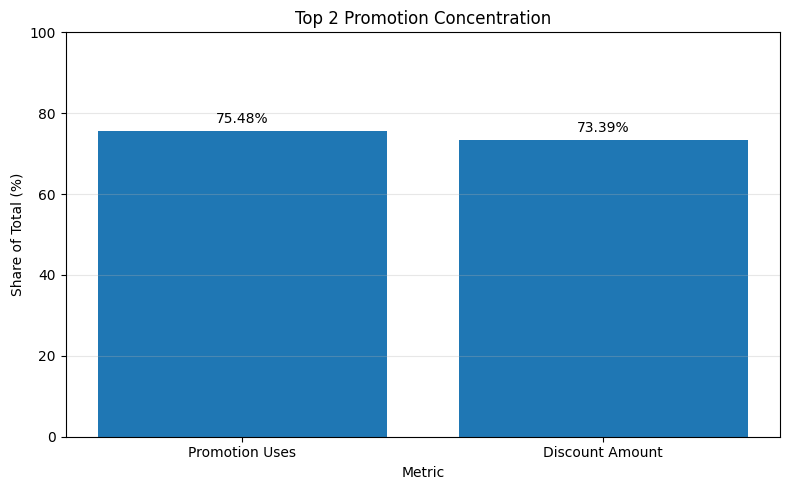

In [33]:
# Create a bar chart to compare promotion usage and discount concentration

concentration_data = pd.DataFrame({
    "Metric": [
        "Promotion Uses",
        "Discount Amount"
    ],
    "Share (%)": [
        uses_concentration,
        discount_concentration
    ]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    concentration_data["Metric"],
    concentration_data["Share (%)"]
)

plt.title("Top 2 Promotion Concentration")
plt.xlabel("Metric")
plt.ylabel("Share of Total (%)")

plt.ylim(0, 100)

# Add percentage labels above each bar
for bar, value in zip(bars, concentration_data["Share (%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The two leading promotions account for 75.48% of all promotion uses and 73.39% of the total discount amount.

This indicates a very high level of promotional concentration: although 21 unique promotions were recorded, most promotional activity and monetary impact came from only two offers.

The similar concentration levels for usage and discount amount also suggest that the dominance of these promotions is driven by both high customer participation and substantial overall promotional value.

## Monthly Average Discount per Use

This section analyzes the average discount amount associated with each promotion use by month, helping identify periods in which promotional activity had a higher monetary cost per redemption.

In [34]:
# Calculate the average discount amount per promotion use for each month

monthly_promotions["Average Discount per Use"] = (
    monthly_promotions["Discount Amount"] / monthly_promotions["Uses"]
)

monthly_promotions[
    ["Date", "Uses", "Discount Amount", "Average Discount per Use"]
].style.format({
    "Uses": "{:,.0f}",
    "Discount Amount": "${:,.2f}",
    "Average Discount per Use": "${:,.2f}"
})

,Date,Uses,Discount Amount,Average Discount per Use
0,2025-03-01 00:00:00,650,"$6,471.27",$9.96
1,2025-04-01 00:00:00,514,"$5,596.78",$10.89
2,2025-05-01 00:00:00,597,"$6,346.34",$10.63
3,2025-06-01 00:00:00,716,"$7,404.55",$10.34
4,2025-07-01 00:00:00,594,"$6,924.22",$11.66
5,2025-08-01 00:00:00,608,"$6,499.91",$10.69
6,2025-09-01 00:00:00,615,"$6,494.46",$10.56
7,2025-10-01 00:00:00,677,"$7,237.65",$10.69
8,2025-11-01 00:00:00,639,"$6,214.21",$9.72
9,2025-12-01 00:00:00,735,"$7,205.55",$9.80


### Monthly Average Discount per Use Visualization

The following line chart shows how the average discount amount per promotion use changed over time, helping identify months with unusually high or low promotional cost per redemption.

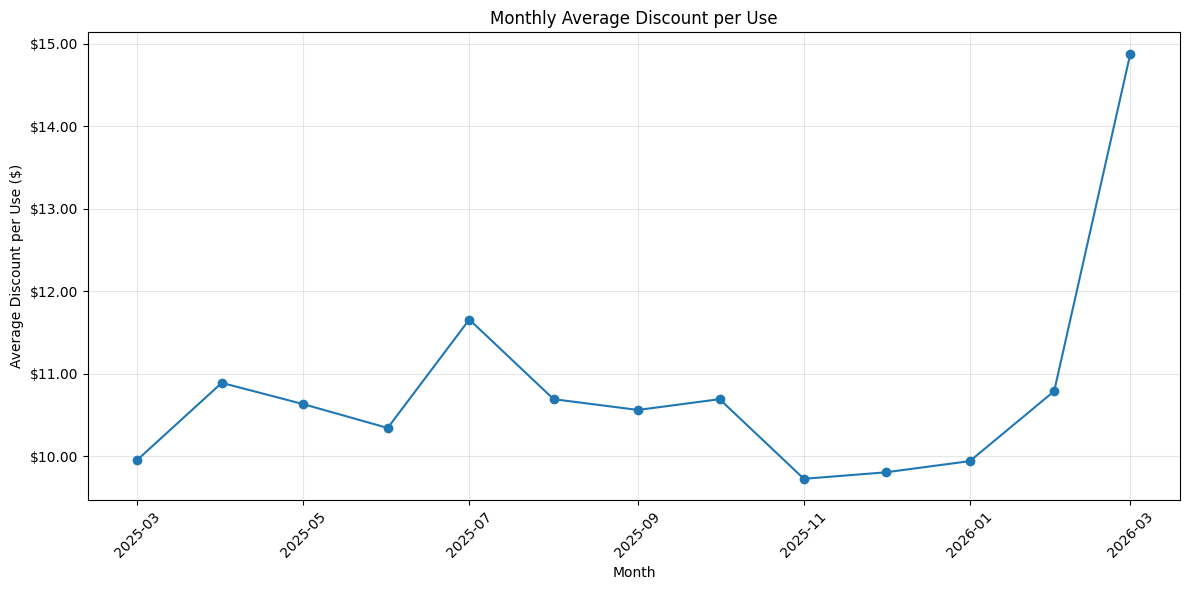

In [35]:
# Create a line chart to visualize the monthly average discount per promotion use

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_promotions["Date"],
    monthly_promotions["Average Discount per Use"],
    marker="o"
)

plt.title("Monthly Average Discount per Use")
plt.xlabel("Month")
plt.ylabel("Average Discount per Use ($)")

# Format the vertical axis as currency
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.2f}")
)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The average discount per promotion use remained relatively stable for most of the analyzed period, generally ranging between approximately $9.72 and $11.66 per redemption.

March 2026 stands out clearly, reaching an average discount of $14.88 per use, the highest value in the period. This indicates that the increase in total promotional cost during March was driven not only by a higher number of promotion uses, but also by a higher monetary discount per redemption.

The result suggests a shift toward more discount-intensive promotional activity during March 2026 compared with previous months.

## Promotion Usage vs Discount Amount

This section analyzes the relationship between promotion usage and total discount amount, helping identify promotions that combine high customer participation with high monetary impact.

In [36]:
# Create a combined dataset to compare promotion uses with total discount amount

promotion_comparison = (
    df.groupby("Promotion")
    .agg({
        "Uses": "sum",
        "Discount Amount": "sum"
    })
    .reset_index()
)

promotion_comparison.head()

,Promotion,Uses,Discount Amount
0,%DESC. AJUSTE APPS,51,92.55
1,10% DESC. DINERS,44,255.42
2,10% DESCUENTO BARRA,121,449.97
3,10% DESCUENTO VIVE MAS,1,53.96
4,10% GRANDE TABLE,2438,21141.53


### Promotion Usage vs Discount Amount Visualization

The following scatter plot compares the total number of uses of each promotion with its total discount amount, helping identify high-impact promotions and unusual patterns in promotional activity.

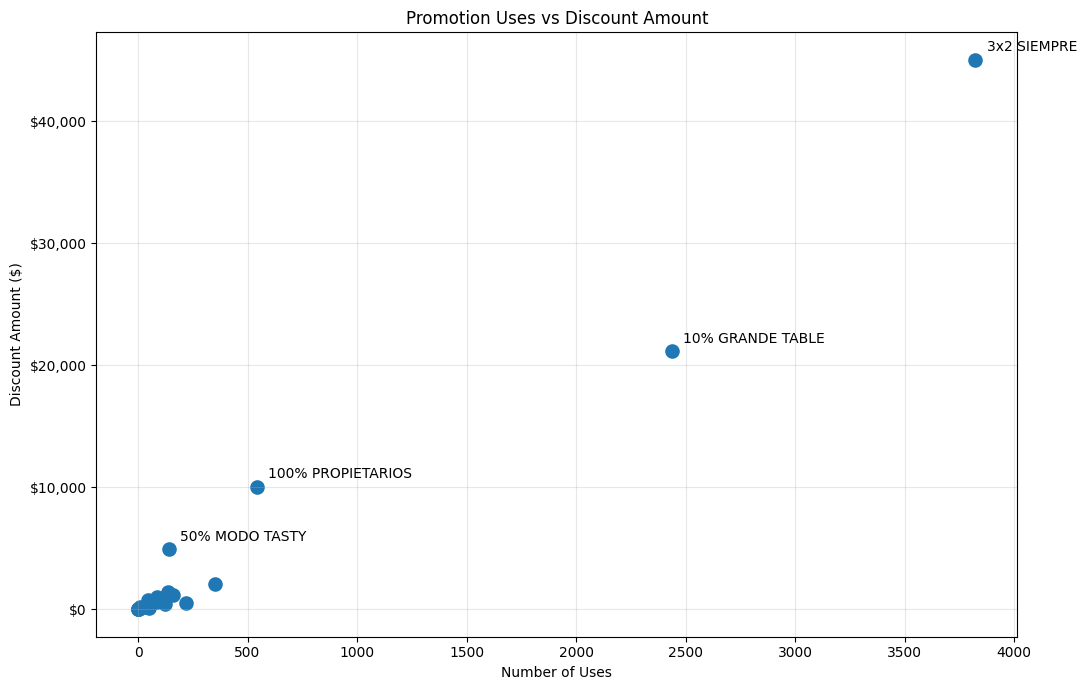

In [37]:
# Create a scatter plot and label the most relevant promotions

plt.figure(figsize=(11, 7))

plt.scatter(
    promotion_comparison["Uses"],
    promotion_comparison["Discount Amount"],
    s=90
)

plt.title("Promotion Uses vs Discount Amount")
plt.xlabel("Number of Uses")
plt.ylabel("Discount Amount ($)")

# Format the vertical axis as currency
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Promotions selected for labeling because of their high usage or monetary impact
promotions_to_label = [
    "3x2 SIEMPRE",
    "10% GRANDE TABLE",
    "100% PROPIETARIOS",
    "50% MODO TASTY"
]

# Add labels only to the most relevant promotion points
for _, row in promotion_comparison.iterrows():
    if row["Promotion"] in promotions_to_label:
        plt.annotate(
            row["Promotion"],
            (row["Uses"], row["Discount Amount"]),
            xytext=(8, 6),
            textcoords="offset points"
        )

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The scatter plot shows a strong positive relationship between promotion usage and total discount amount, with the most frequently used promotions also generating the greatest monetary impact.

`3x2 SIEMPRE` and `10% GRANDE TABLE` stand out clearly as the dominant promotions in both usage and total discount value. `100% PROPIETARIOS` also shows a significant monetary impact despite having substantially fewer uses.

`50% MODO TASTY` is particularly noteworthy because it generates a relatively high discount amount despite its lower number of uses, reflecting the higher average discount per redemption identified earlier.

## Promotion Analysis Summary

The promotions analysis shows that the restaurant recorded 8,295 promotion uses and a total discount amount of $90,189.53 during the analyzed period, across 21 unique promotions.

Promotional activity was highly concentrated. `3x2 SIEMPRE` and `10% GRANDE TABLE` together accounted for 75.48% of all promotion uses and 73.39% of the total discount amount, making them the dominant promotional offers.

`3x2 SIEMPRE` generated the highest overall promotional impact, with 3,823 uses and $45,045.70 in total discounts. `10% GRANDE TABLE` followed with 2,438 uses and $21,141.53 in total discounts.

Average discount per use varied significantly across individual promotions. Some promotions showed high values but were based on very few uses, while `50% MODO TASTY` stood out as a more meaningful high-discount promotion, combining 141 uses with an average discount of $35.07 per redemption.

Monthly promotional activity remained relatively stable for most of the period. However, March 2026 represented a clear outlier, recording 792 promotion uses, $11,786.55 in total discounts, and the highest monthly average discount per use at $14.88.

Overall, the results indicate that promotional activity is driven primarily by a small number of offers, while March 2026 experienced an unusually high level of both promotional participation and discount intensity.

---

## Author

**Guido Acosta**

Data Analyst Portfolio Project

GitHub Portfolio – 2026